In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv("placement.csv")

In [3]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


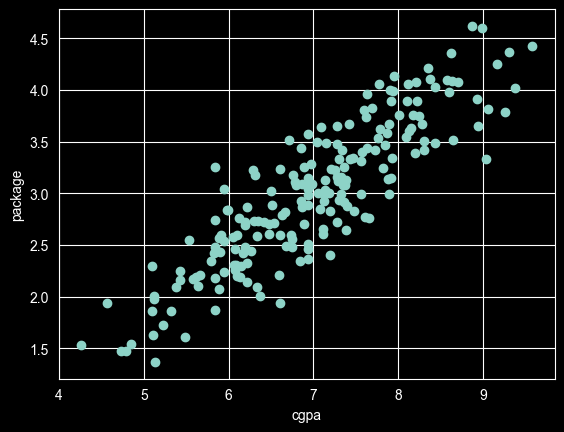

In [4]:
plt.scatter(df['cgpa'], df['package'])
plt.xlabel("cgpa")
plt.ylabel("package")
plt.show()

In [5]:
X = df.iloc[:, 0:1]
y = df.iloc[:, -1]

In [6]:
y

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2)

In [8]:
from sklearn.linear_model import LinearRegression

In [9]:
lr = LinearRegression()

In [10]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


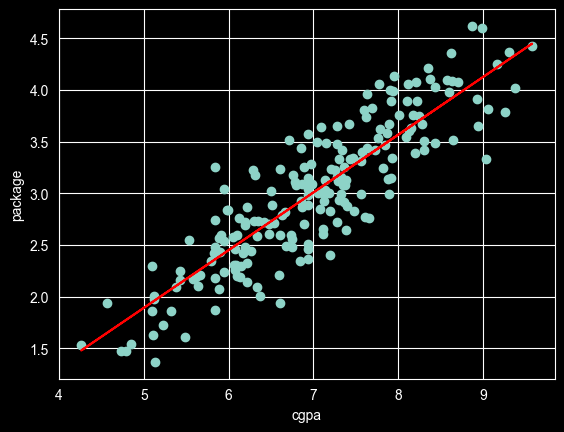

In [11]:
plt.scatter(df['cgpa'], df['package'])
plt.plot(X_train, lr.predict(X_train), color = 'red')
plt.xlabel("cgpa")
plt.ylabel("package")
plt.show()

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [15]:
y_pred = lr.predict(X_test)

In [14]:
y_test.values

array([4.1 , 3.49, 2.08, 2.33, 1.94, 1.48, 1.86, 3.09, 4.21, 2.87, 3.65,
       4.  , 2.89, 2.6 , 2.99, 3.25, 1.86, 3.67, 2.37, 3.42, 2.48, 3.65,
       2.6 , 2.83, 4.08, 2.56, 3.58, 3.81, 4.09, 2.01, 3.63, 2.92, 3.51,
       1.94, 2.21, 3.34, 3.34, 3.23, 2.01, 2.61])

In [16]:
print("MAE: ", mean_absolute_error(y_test, y_pred))

MAE:  0.2884710931878175


In [17]:
print("MSE: ", mean_squared_error(y_test, y_pred))

MSE:  0.12129235313495527


In [18]:
print("RMSE", np.sqrt(mean_squared_error(y_test, y_pred)))

RMSE 0.34827051717731616


In [19]:
print("R2 Score: ", r2_score(y_test, y_pred))

R2 Score:  0.780730147510384


In [22]:
# Adjusted R2 Score
r2 = r2_score(y_test, y_pred)

In [23]:
X_test.shape

(40, 1)

In [24]:
1 - ((1- r2)*(40-1)/(40-1-1))

0.7749598882343415

In [26]:
new_df = df.copy()
new_df['random_feature'] = np.random.random(200)

new_df = new_df[['cgpa', 'random_feature', 'package']]
new_df.head()

,cgpa,random_feature,package
0,6.89,0.040598,3.26
1,5.12,0.991538,1.98
2,7.82,0.902766,3.25
3,7.42,0.350058,3.67
4,6.94,0.855207,3.57


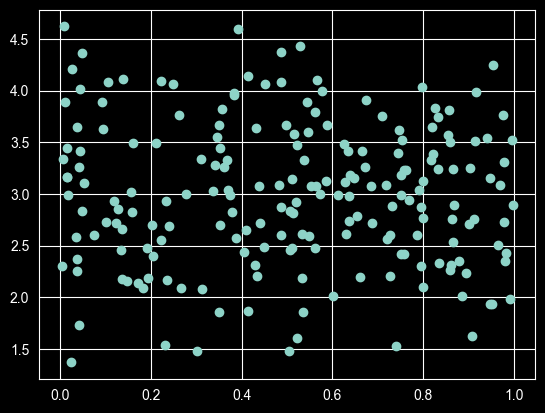

In [27]:
plt.scatter(new_df['random_feature'], new_df['package'])

In [28]:
X = new_df.iloc[:, 0:2]
y = new_df.iloc[:, -1]

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2)

In [30]:
lr = LinearRegression()

In [31]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [32]:
y_pred = lr.predict(X_test)

In [33]:
print("R2 Score: ", r2_score(y_test, y_pred))

R2 Score:  0.7823075426486815


In [34]:
r2 = r2_score(y_test, y_pred)

In [36]:
1 - ((1- r2)*(40-1)/(40-1-2))

0.7705403827918536

In [37]:
new_df2 = df.copy()
new_df2['iq'] = new_df2['package'] + (np.random.randint(-12, 12, 200) / 10)
new_df2 = new_df2[['cgpa', 'iq', 'package']]

In [39]:
new_df2.head()

,cgpa,iq,package
0,6.89,4.36,3.26
1,5.12,1.88,1.98
2,7.82,3.25,3.25
3,7.42,4.57,3.67
4,6.94,4.07,3.57


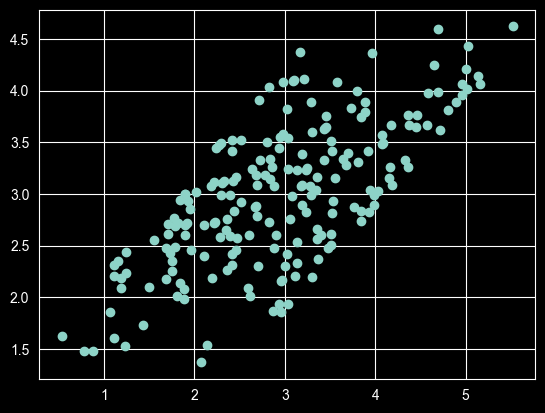

In [41]:
plt.scatter(new_df2['iq'], new_df2['package'])

In [42]:
X = new_df2.iloc[:, 0:2]
y = new_df2.iloc[:, -1]

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2)

In [44]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

In [45]:
print("R2 score ", r2_score(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

R2 score  0.7853368430022838


In [46]:
1 - ((1- r2)*(40-1)/(40-1-2))

0.7737334291105153